# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [3]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [4]:
import sys
print(sys.version)

3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]


In [5]:
#!pip install tensorflow

In [6]:
import tensorflow as tf

I0000 00:00:1785736767.772929    9111 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785736767.802603    9111 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785736768.484671    9111 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [7]:
tf.__version__

'2.21.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [8]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [9]:
X = pd.read_csv('Features_lim_2.csv')

In [10]:
y = np.genfromtxt('Labels_lim_2.txt')

In [11]:
X.values.shape

(5000, 24)

In [12]:
X.head()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [13]:
y

array([0., 0., 0., ..., 0., 1., 0.], shape=(5000,))

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [14]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.float64(0.0): np.int64(4189), np.float64(1.0): np.int64(811)}


In [15]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [16]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 200, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [17]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'MultiOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'OptimizerMap',
 'RMSprop',
 'SGD',
 'ScheduleFreeAdamW',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [18]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [19]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [20]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura



/home/cristobal/venv-tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1785736769.603268    9111 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13567 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema?


**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.


In [22]:
model_1 = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model_1.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model_1.add(Dense(20, activation='relu'))
model_1.add(Dense(20, activation='relu'))

# Agrega capa de salida

model_1.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_1 = mynet_1.history['val_accuracy'][-1]
val_loss_1 = mynet_1.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_1:.4f}")
print(f"val_loss: {val_loss_1:.4f}")



I0000 00:00:1785736771.853085   18656 service.cc:153] XLA service 0x7bdb54042a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785736771.853102   18656 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785736771.883335   18656 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785736772.144707   18656 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1785736772.148857   18656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1614__.9
I0000 00:00:1785736772.675168   18656 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set inst

val_accuracy: 0.6950
val_loss: 110.9327


### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy: Esperaría algo cercano al rango del SVM, quizás un poco por debajo (~85-92%), ya que la red tiene una capacidad de representación al menos comparable y el problema no parece requerir relaciones extremadamente no lineales. No debería ser mucho peor, salvo que algo en la configuración (learning rate, escalado de los datos, número de épocas) esté impidiendo que converja bien.

In [23]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100


I0000 00:00:1785736781.184308   18656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13425__.8


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3338 - loss: 21537.3594 - val_accuracy: 0.8050 - val_loss: 6231.8735
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8334 - loss: 6545.3198 - val_accuracy: 0.8100 - val_loss: 4629.4688
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6687 - loss: 3450.2334 - val_accuracy: 0.6325 - val_loss: 2951.3757
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7253 - loss: 2399.4783 - val_accuracy: 0.6938 - val_loss: 2431.0801
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6675 - loss: 2080.9758 - val_accuracy: 0.6888 - val_loss: 2221.9067
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6800 - loss: 1904.0892 - val_accuracy: 0.6938 - val_loss: 2086.9734
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6869 - loss: 1743.4185 - val_accuracy: 0.6837 - val_loss: 1936.3762
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6891 - loss: 1

Accuracy para entrenamiento y validación no se ven muy bien

Grafiquemos cómo se ve esto en cada época

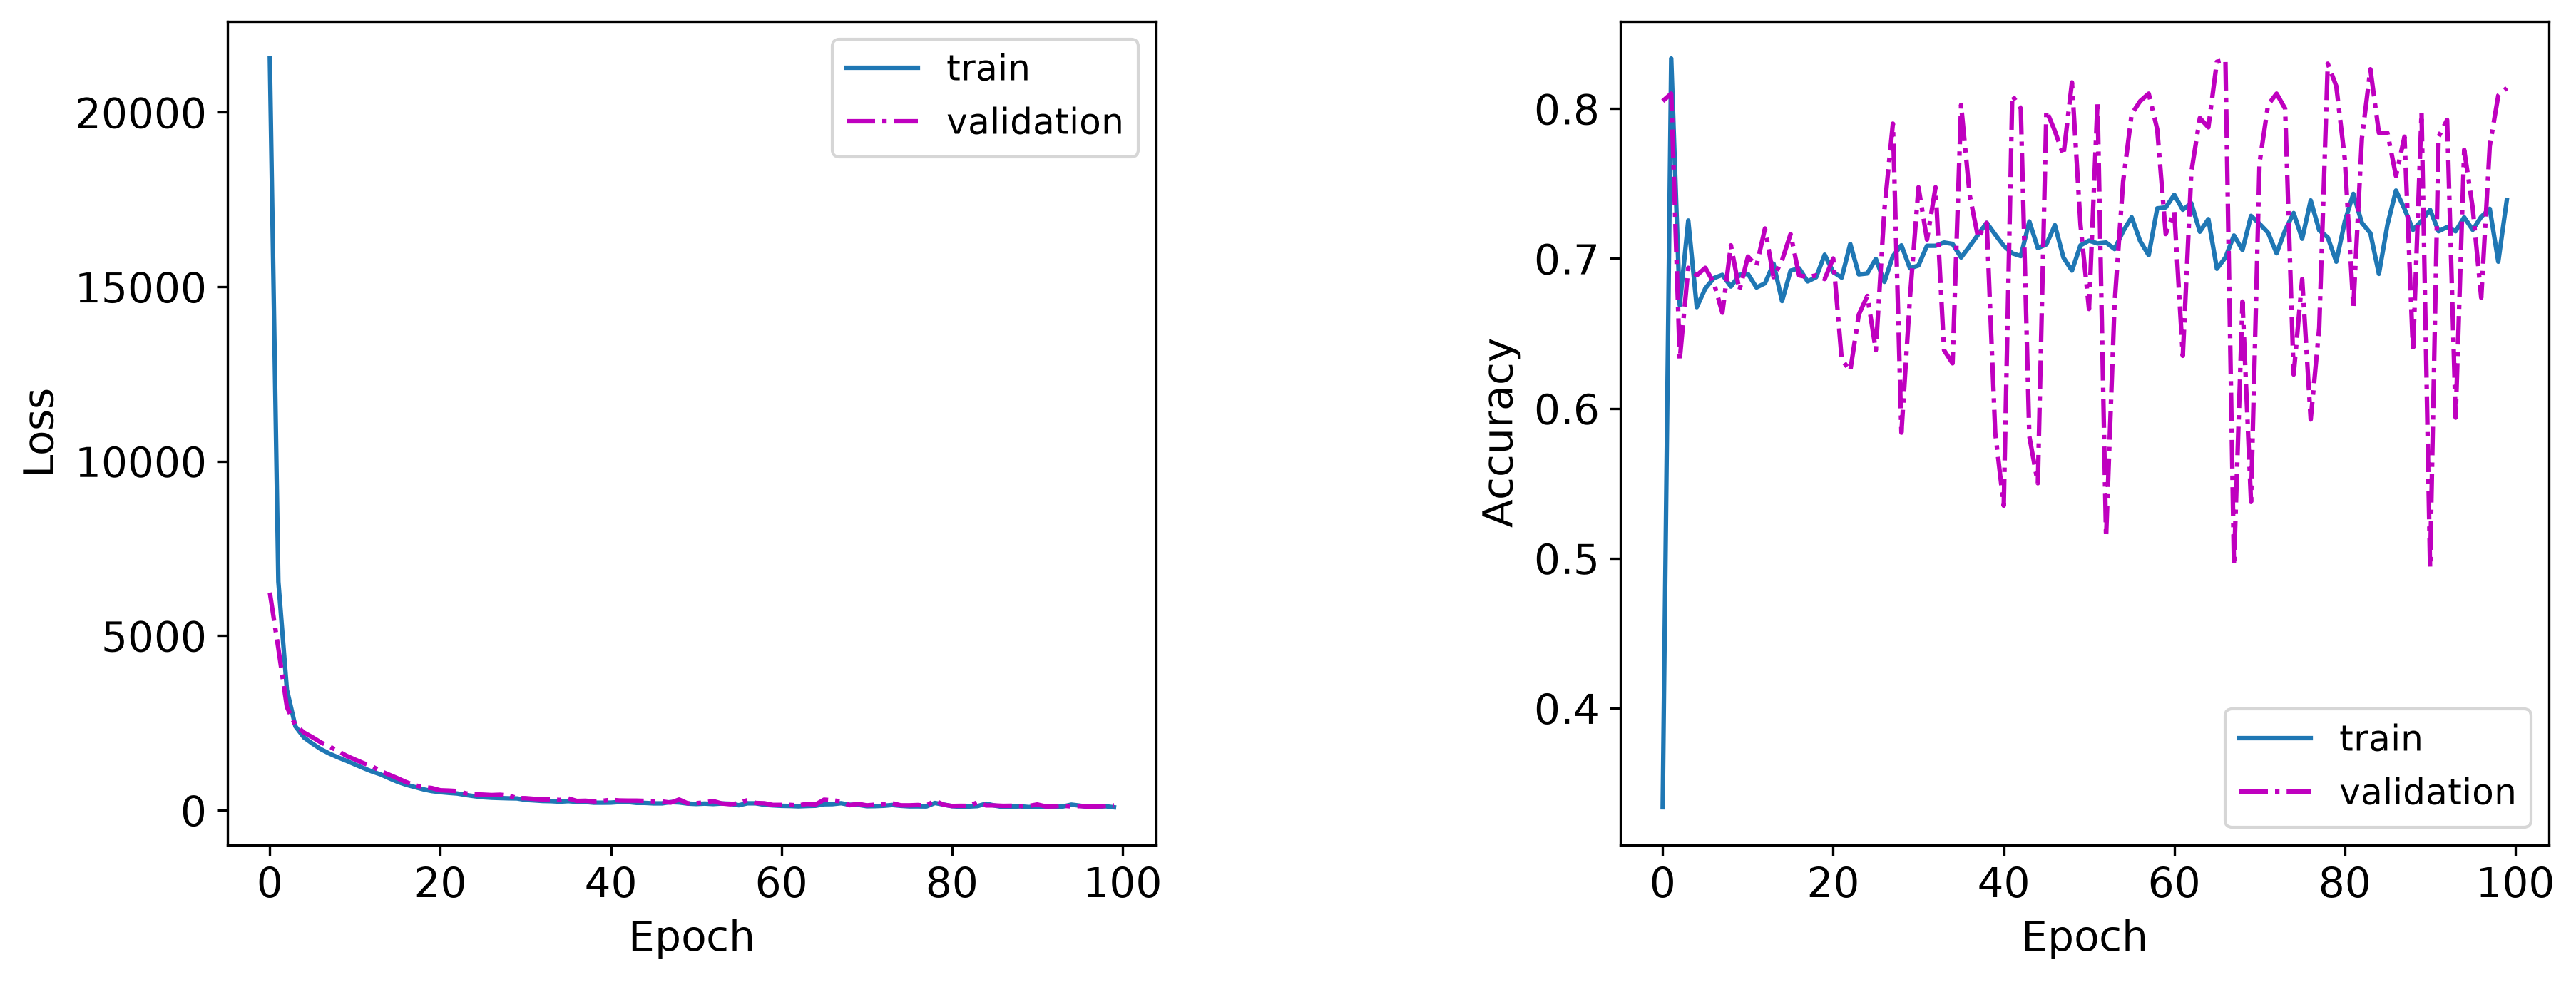

In [24]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.
2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?
3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

**Respuestas:**

1. Al correr `X.describe()` se ve que las columnas tienen escalas completamente distintas: variables como `MET` o `P2` van desde ~0 hasta cientos de miles (mean ~64.000 y ~150.000 respectivamente), mientras que otras como `P1` (ángulos) van apenas de -4 a 4, y columnas como `Total_leptons` o `Total_b` son enteros pequeños de 0 a ~13.

2. Sí: esa diferencia de escalas es justo lo que afecta al descenso por gradiente. Las columnas con valores muy grandes (del orden de 10^5-10^6) dominan la magnitud de los gradientes y de la pérdida inicial, mientras que las columnas con valores pequeños (los ángulos, por ejemplo) prácticamente no aportan señal al principio del entrenamiento. Esto hace que la optimización sea inestable o muy lenta, porque el gradiente "empuja" mucho más fuerte en las direcciones de las variables con rangos grandes que en las demás, en vez de ajustar todos los pesos de forma balanceada.

3. No alcanza por sí sola. La curva de pérdida nos dice si el modelo está aprendiendo (bajando) o no, pero no nos dice *por qué* no está aprendiendo bien. Para diagnosticar la causa hay que mirar también los datos de entrada (como hicimos con `X.describe()`), la arquitectura, y las métricas (accuracy, val_accuracy) en conjunto con la pérdida — una pérdida que baja muy poco puede deberse a mal escalado, a un learning rate mal elegido, a una arquitectura insuficiente, etc., y cada causa se diagnostica de forma distinta.

In [25]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


### Nos olvidamos de escalar (por qué es necesario??)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [28]:
scaler.fit(X_train)

StandardScaler()

In [29]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [30]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/home/cristobal/venv-tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1785736789.817031   18655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25296__.8


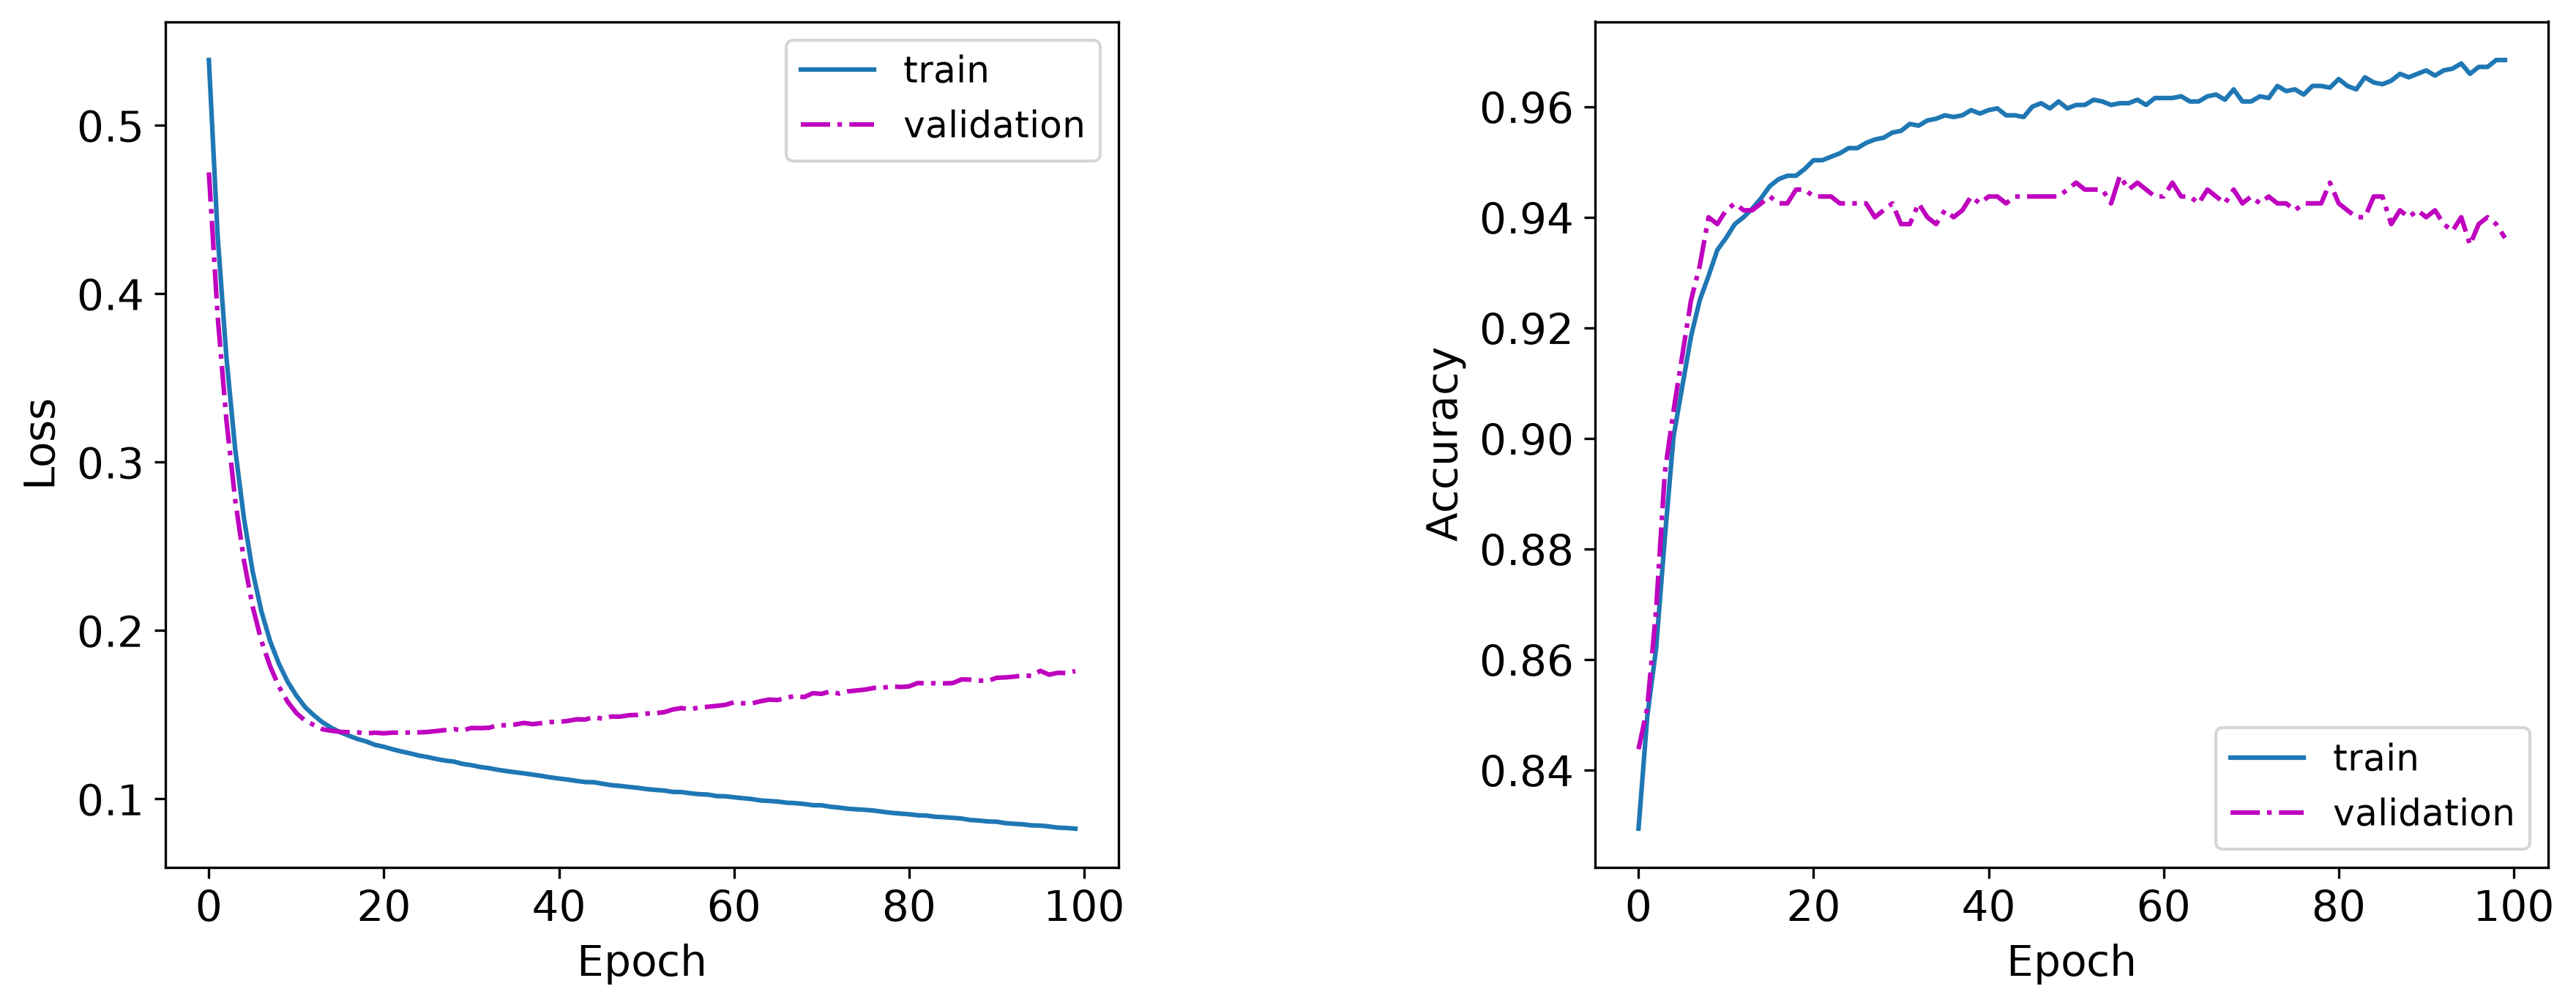

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

In [32]:
print("acc:", mynet_st.history["accuracy"][-1])
print("val_acc:", mynet_st.history["val_accuracy"][-1])
print("val_loss:", mynet_st.history["val_loss"][-1])
print("loss:", mynet_st.history["loss"][-1])


acc: 0.9684374928474426
val_acc: 0.9362499713897705
val_loss: 0.17595967650413513
loss: 0.08239132165908813


#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?

Si hay una separación entre ambas curvas desde aproximadamente las 20 epocas y esta crece de manera constante mientras mas epocas pasan

2. ¿esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.

Califica como overfitting severo ya que el accuracy es mejor en 2.6% lo que no parece mucho pero cuando se considera que la función de perdida tiene una diferencia de casi el doble

3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?

Si tiene sentido aplicar la regularización para controlar el overfitting


### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) |0.9337|0.1734|tiene un buen balance entre accuracy y loss|
| 3 capas ocultas |0.9350|0.1973|La capa extra resulto en una accuracy prácticamente igual al baseline, pero un val_loss mayor. La capa extra no aporta en este problema y en cambio agrega parámetros que favorecen un poco más el sobreajuste.|
| Capas de 5 neuronas |0.9463|0.1487|Es la mejor variante, tanto en accuracy como en loss. Sugiere que el problema no necesita mucha capacidad.|
| Capas de 100 neuronas |0.9187|0.4337|La peor variante: el loss se dispara aunque el accuracy no cae tanto. Lo que indica un sobreajuste severo.|
| Activación tanh |0.9312|0.1936|Resultados similares al baseline, sin mejora clara. tanh no aporta ventaja aquí porque el problema no depende de las diferencias entre relu y tanh.|

In [33]:
#baseline (2 capas x 20, relu)
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)
model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño
model.add(Dense(20, activation='relu'))

# Agrega capa de salida
model.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_baseline = model.fit(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_baseline = mynet_baseline.history['val_accuracy'][-1]
val_loss_baseline = mynet_baseline.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_baseline:.4f}")
print(f"val_loss: {val_loss_baseline:.4f}")

I0000 00:00:1785736797.813400   18653 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37167__.8


val_accuracy: 0.9438
val_loss: 0.1685


In [34]:
#3 capas 
model_3 = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)
model_3.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño
model_3.add(Dense(20, activation='relu'))

# Agrega una tercera capa oculta y especificamos el tamaño
model_3.add(Dense(20, activation='relu'))

# Agrega capa de salida
model_3.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_3 = model_3.fit(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_3 = mynet_3.history['val_accuracy'][-1]
val_loss_3 = mynet_3.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_3:.4f}")
print(f"val_loss: {val_loss_3:.4f}")

I0000 00:00:1785736805.493053   18654 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49326__.9


val_accuracy: 0.9325
val_loss: 0.2332


In [35]:
#2 capas x 5
model_2_5 = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)
model_2_5.add(Dense(5, activation='relu', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño
model_2_5.add(Dense(5, activation='relu'))

# Agrega capa de salida
model_2_5.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_2_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_2_5 = model_2_5.fit(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_2_5 = mynet_2_5.history['val_accuracy'][-1]
val_loss_2_5 = mynet_2_5.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_2_5:.4f}")
print(f"val_loss: {val_loss_2_5:.4f}")

I0000 00:00:1785736813.247262   18655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61220__.8


val_accuracy: 0.9400
val_loss: 0.1485


In [36]:
#2 capas x 100
model_2_100 = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)
model_2_100.add(Dense(100, activation='relu', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño
model_2_100.add(Dense(100, activation='relu'))

# Agrega capa de salida
model_2_100.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_2_100.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_2_100 = model_2_100.fit(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_2_100 = mynet_2_100.history['val_accuracy'][-1]
val_loss_2_100 = mynet_2_100.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_2_100:.4f}")
print(f"val_loss: {val_loss_2_100:.4f}")

I0000 00:00:1785736821.476251   18655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73107__.8
I0000 00:00:1785736821.481162   18655 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785736821.783229   18655 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785736822.103729   18655 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


val_accuracy: 0.9275
val_loss: 0.4039


In [37]:
#2 capas x 100
model_2_tanh = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)
model_2_tanh.add(Dense(20, activation='tanh', input_shape=(24,)))

# Agrega una segunda capa oculta y especificamos el tamaño
model_2_tanh.add(Dense(20, activation='tanh'))

# Agrega capa de salida
model_2_tanh.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_2_tanh.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_2_tanh = model_2_tanh.fit(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0
)

# Valores finales para la tabla de comparación
val_acc_2_tanh = mynet_2_tanh.history['val_accuracy'][-1]
val_loss_2_tanh = mynet_2_tanh.history['val_loss'][-1]
print(f"val_accuracy: {val_acc_2_tanh:.4f}")
print(f"val_loss: {val_loss_2_tanh:.4f}")

I0000 00:00:1785736830.120915   18656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84978__.8
I0000 00:00:1785736830.202628   18656 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


val_accuracy: 0.9287
val_loss: 0.1770


### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?
El drop out


- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?
Creo que el early stopping sera mas rapida de entrenar

### Dropout

In [38]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [39]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

I0000 00:00:1785736838.229773   18657 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97005__.10
I0000 00:00:1785736838.311283   18657 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


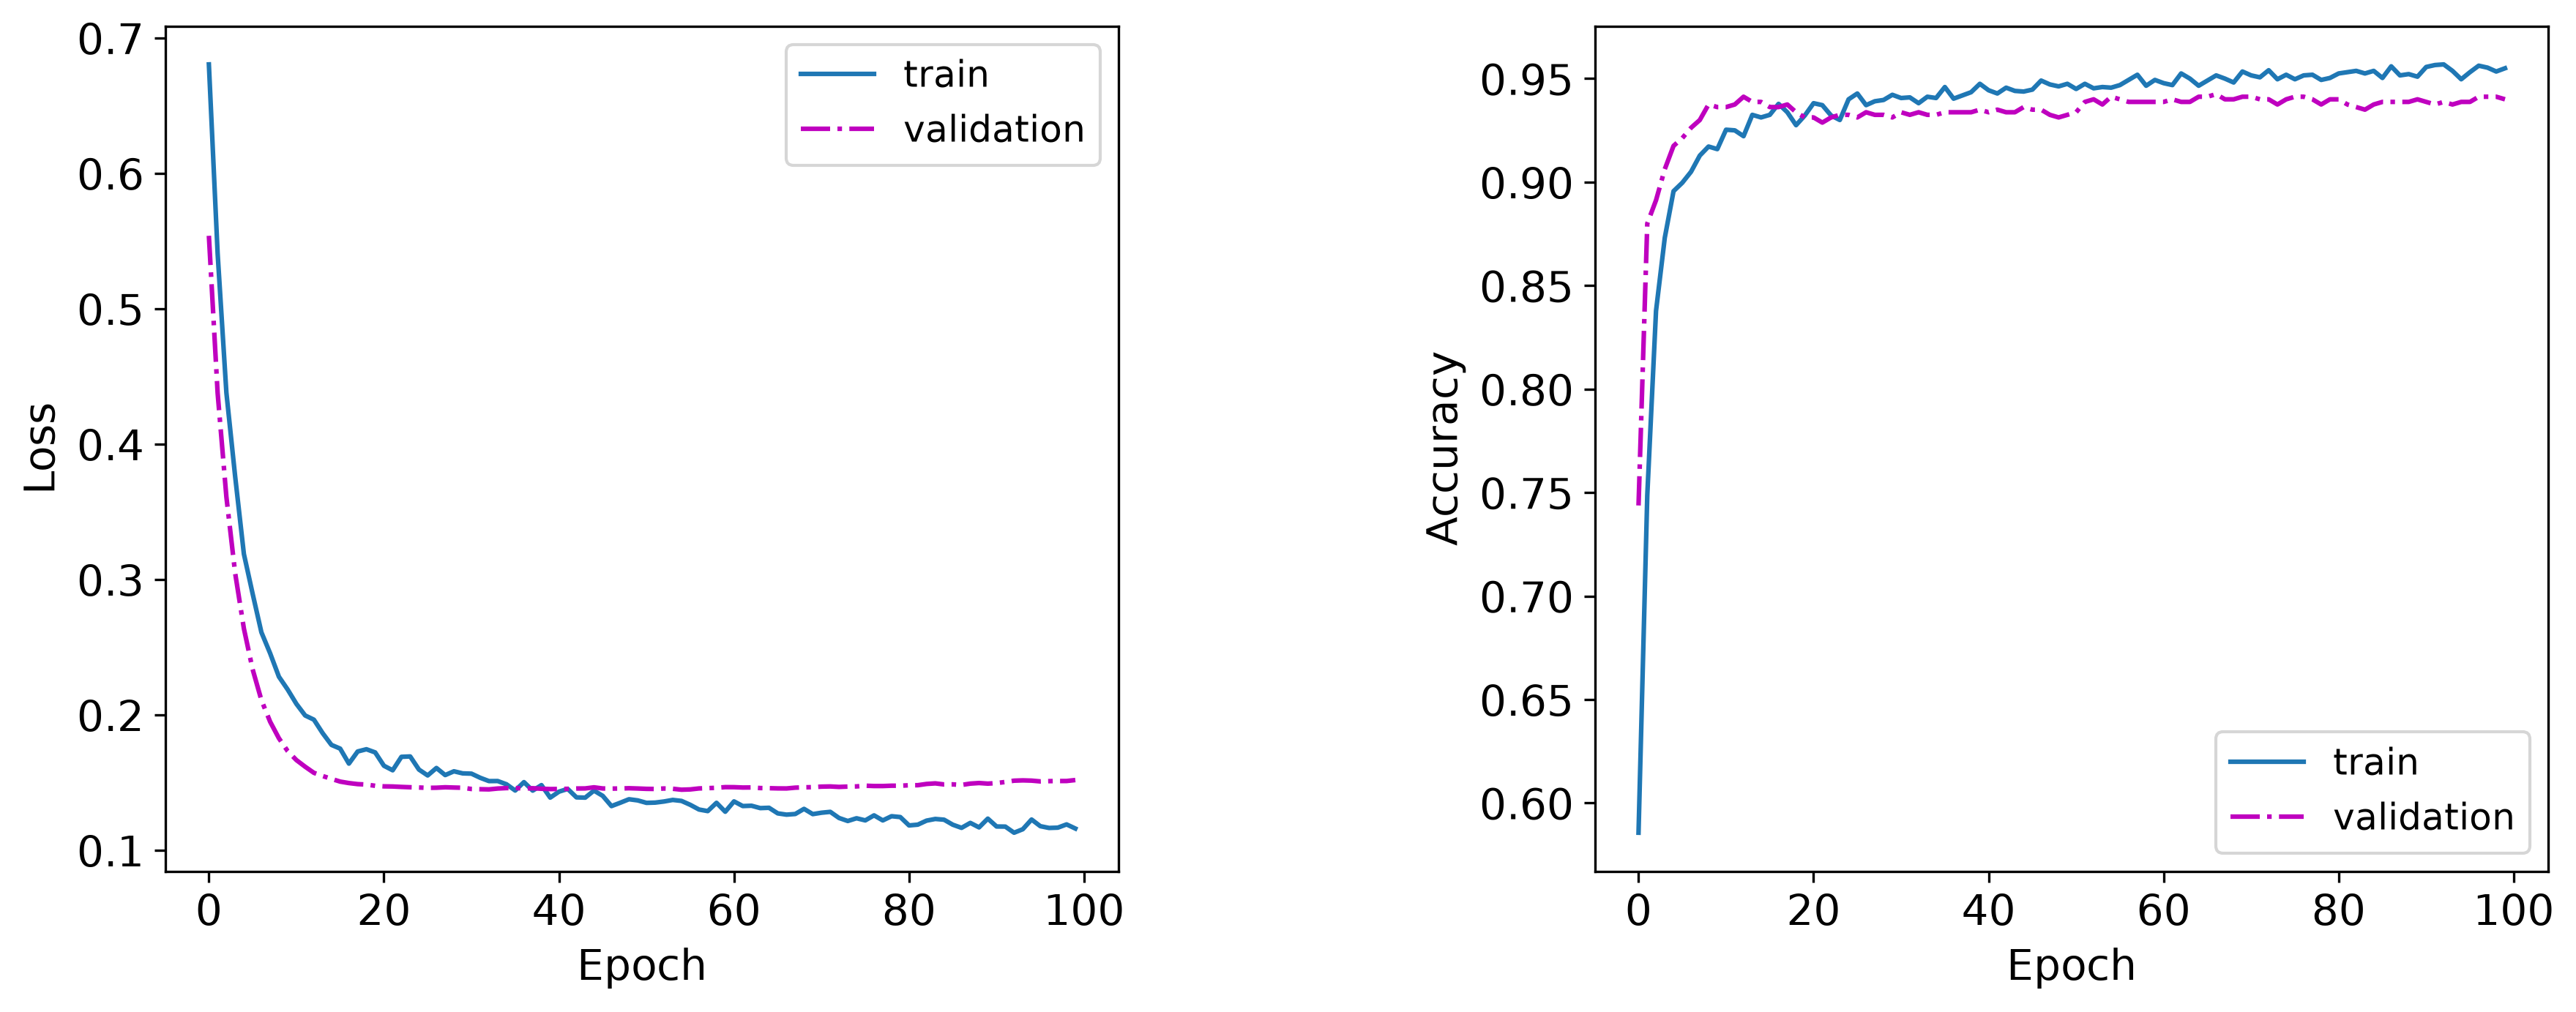

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

In [41]:
model_drop = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_drop.add(Dense(20, activation='relu', input_shape=(24,)))

model_drop.add(Dropout(0.35)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_drop.add(Dense(20, activation='relu'))

model_drop.add(Dropout(0.35)) #fracción de dropout

#Agregamos capa de salida

model_drop.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_drop.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
mynet_drop = model_drop.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)


I0000 00:00:1785736847.037494   18656 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109036__.10


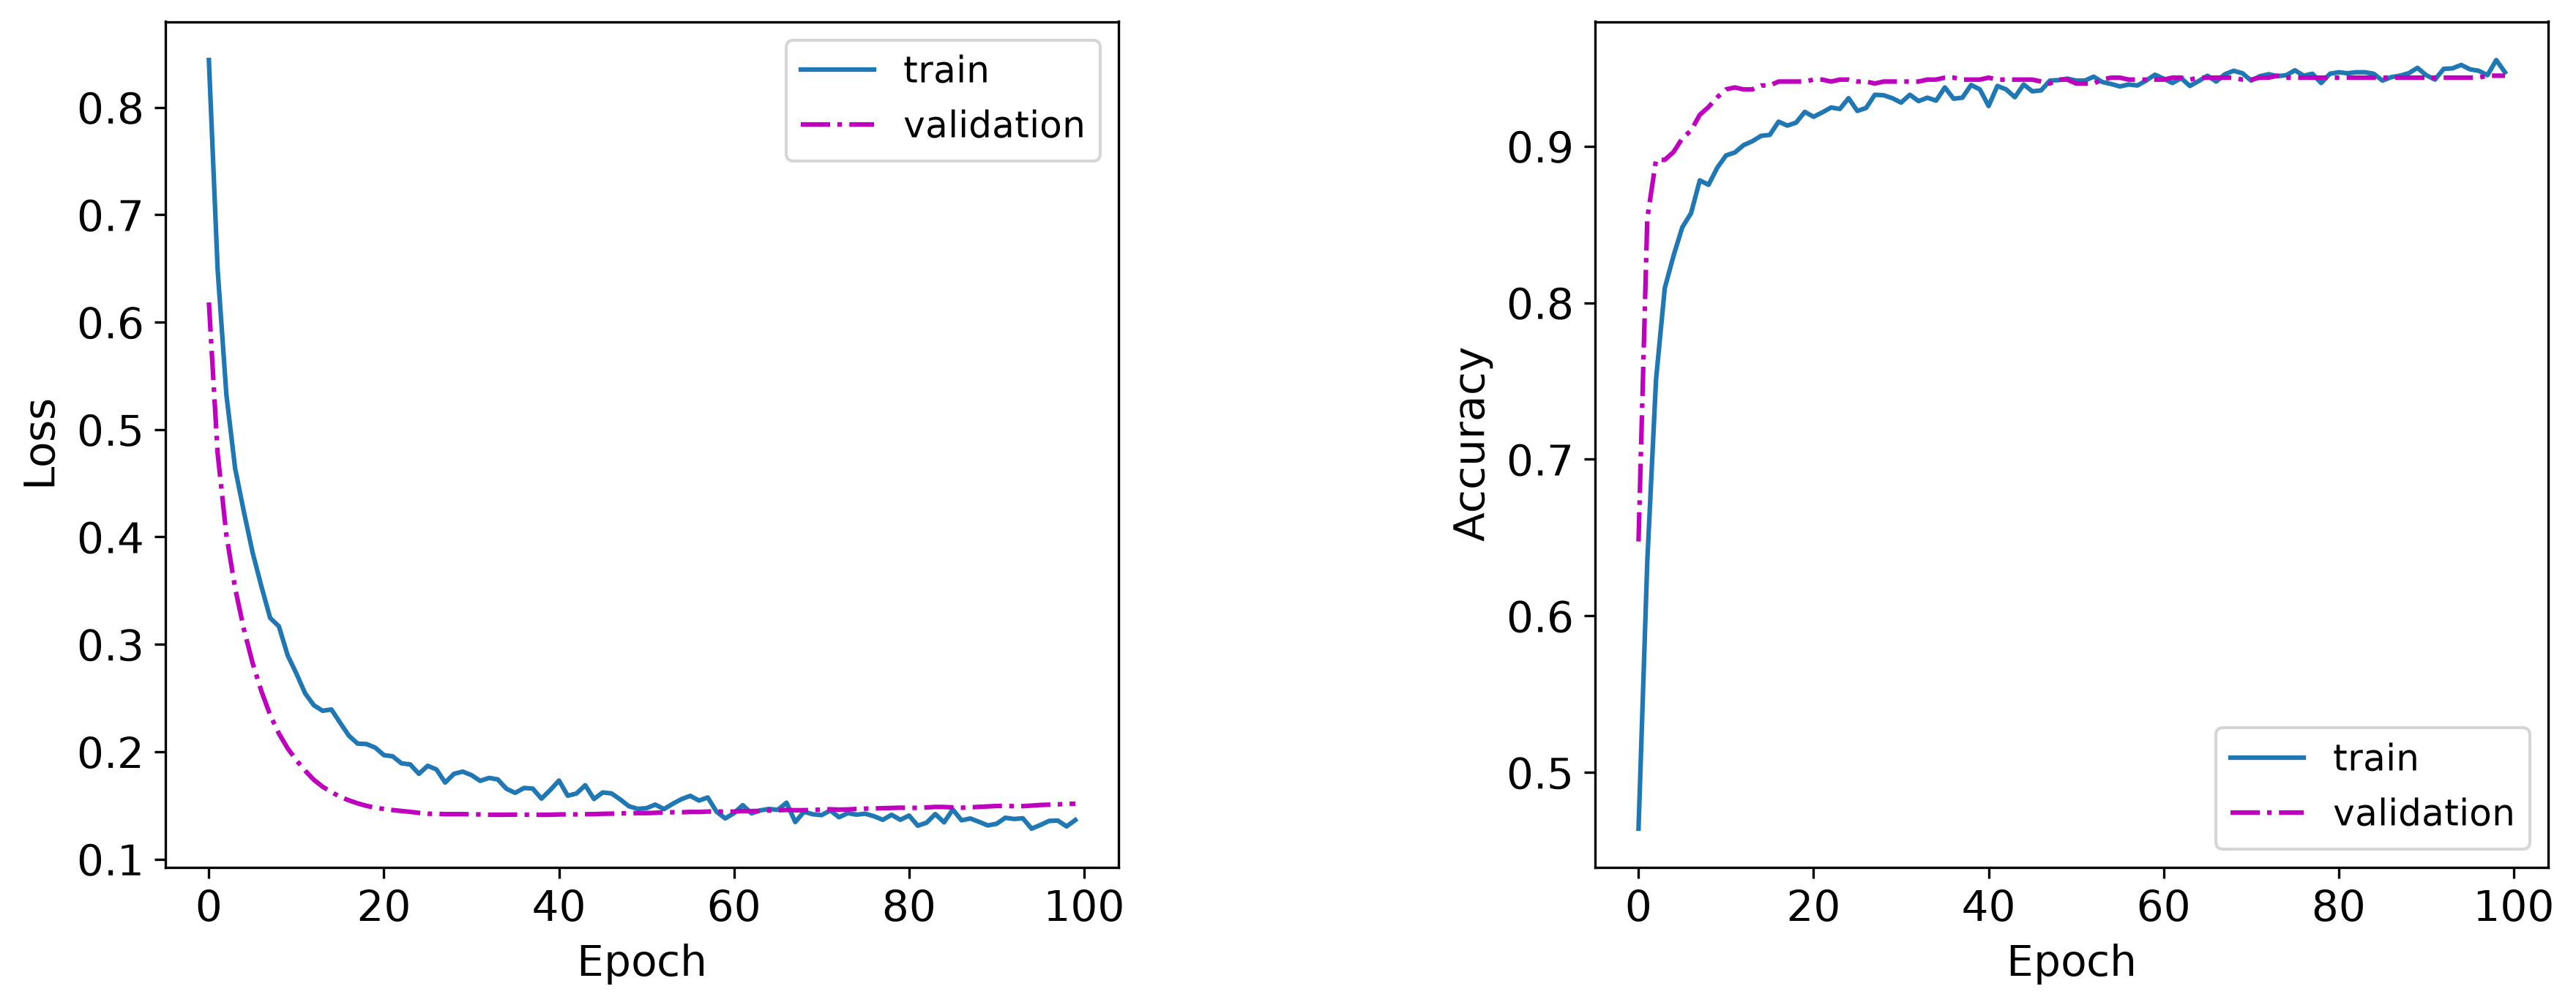

In [42]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_drop.history['loss'], label = 'train')
plt.plot(mynet_drop.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_drop.history['accuracy'], label = 'train')
plt.plot(mynet_drop.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

I0000 00:00:1785736855.137923   18655 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121067__.10


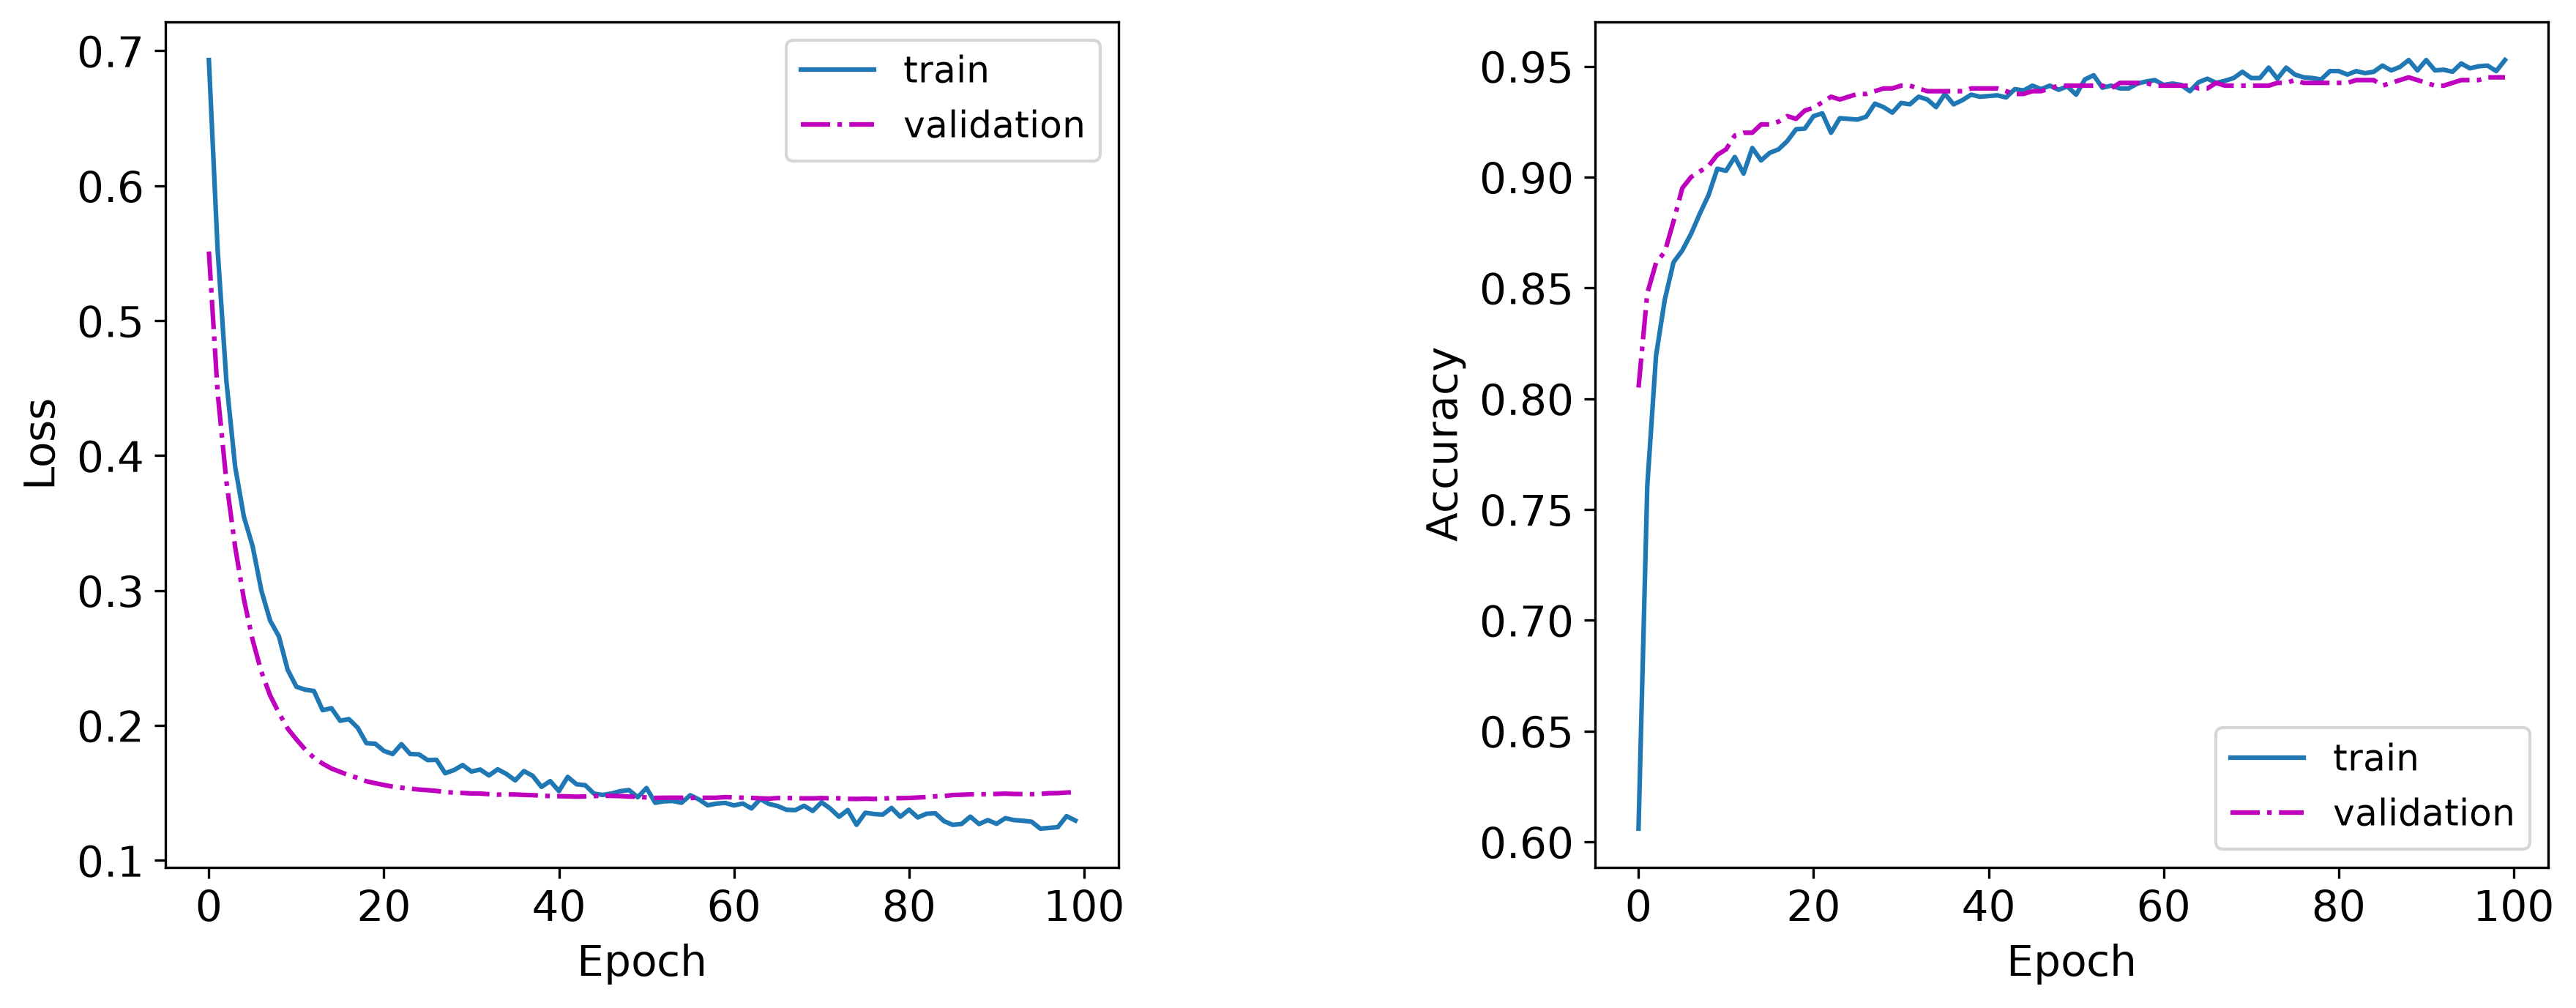

In [43]:
model_d = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_d.add(Dense(20, activation='relu', input_shape=(24,)))

model_d.add(Dropout(0.3)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_d.add(Dense(20, activation='relu'))

model_d.add(Dropout(0.25)) #fracción de dropout

#Agregamos capa de salida

model_d.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_d.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
mynet_d = model_d.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_d.history['loss'], label = 'train')
plt.plot(mynet_d.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_d.history['accuracy'], label = 'train')
plt.plot(mynet_d.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()


### Early Stopping

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

I0000 00:00:1785736863.281568   18657 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132942__.8


Se detuvo en la época: 29


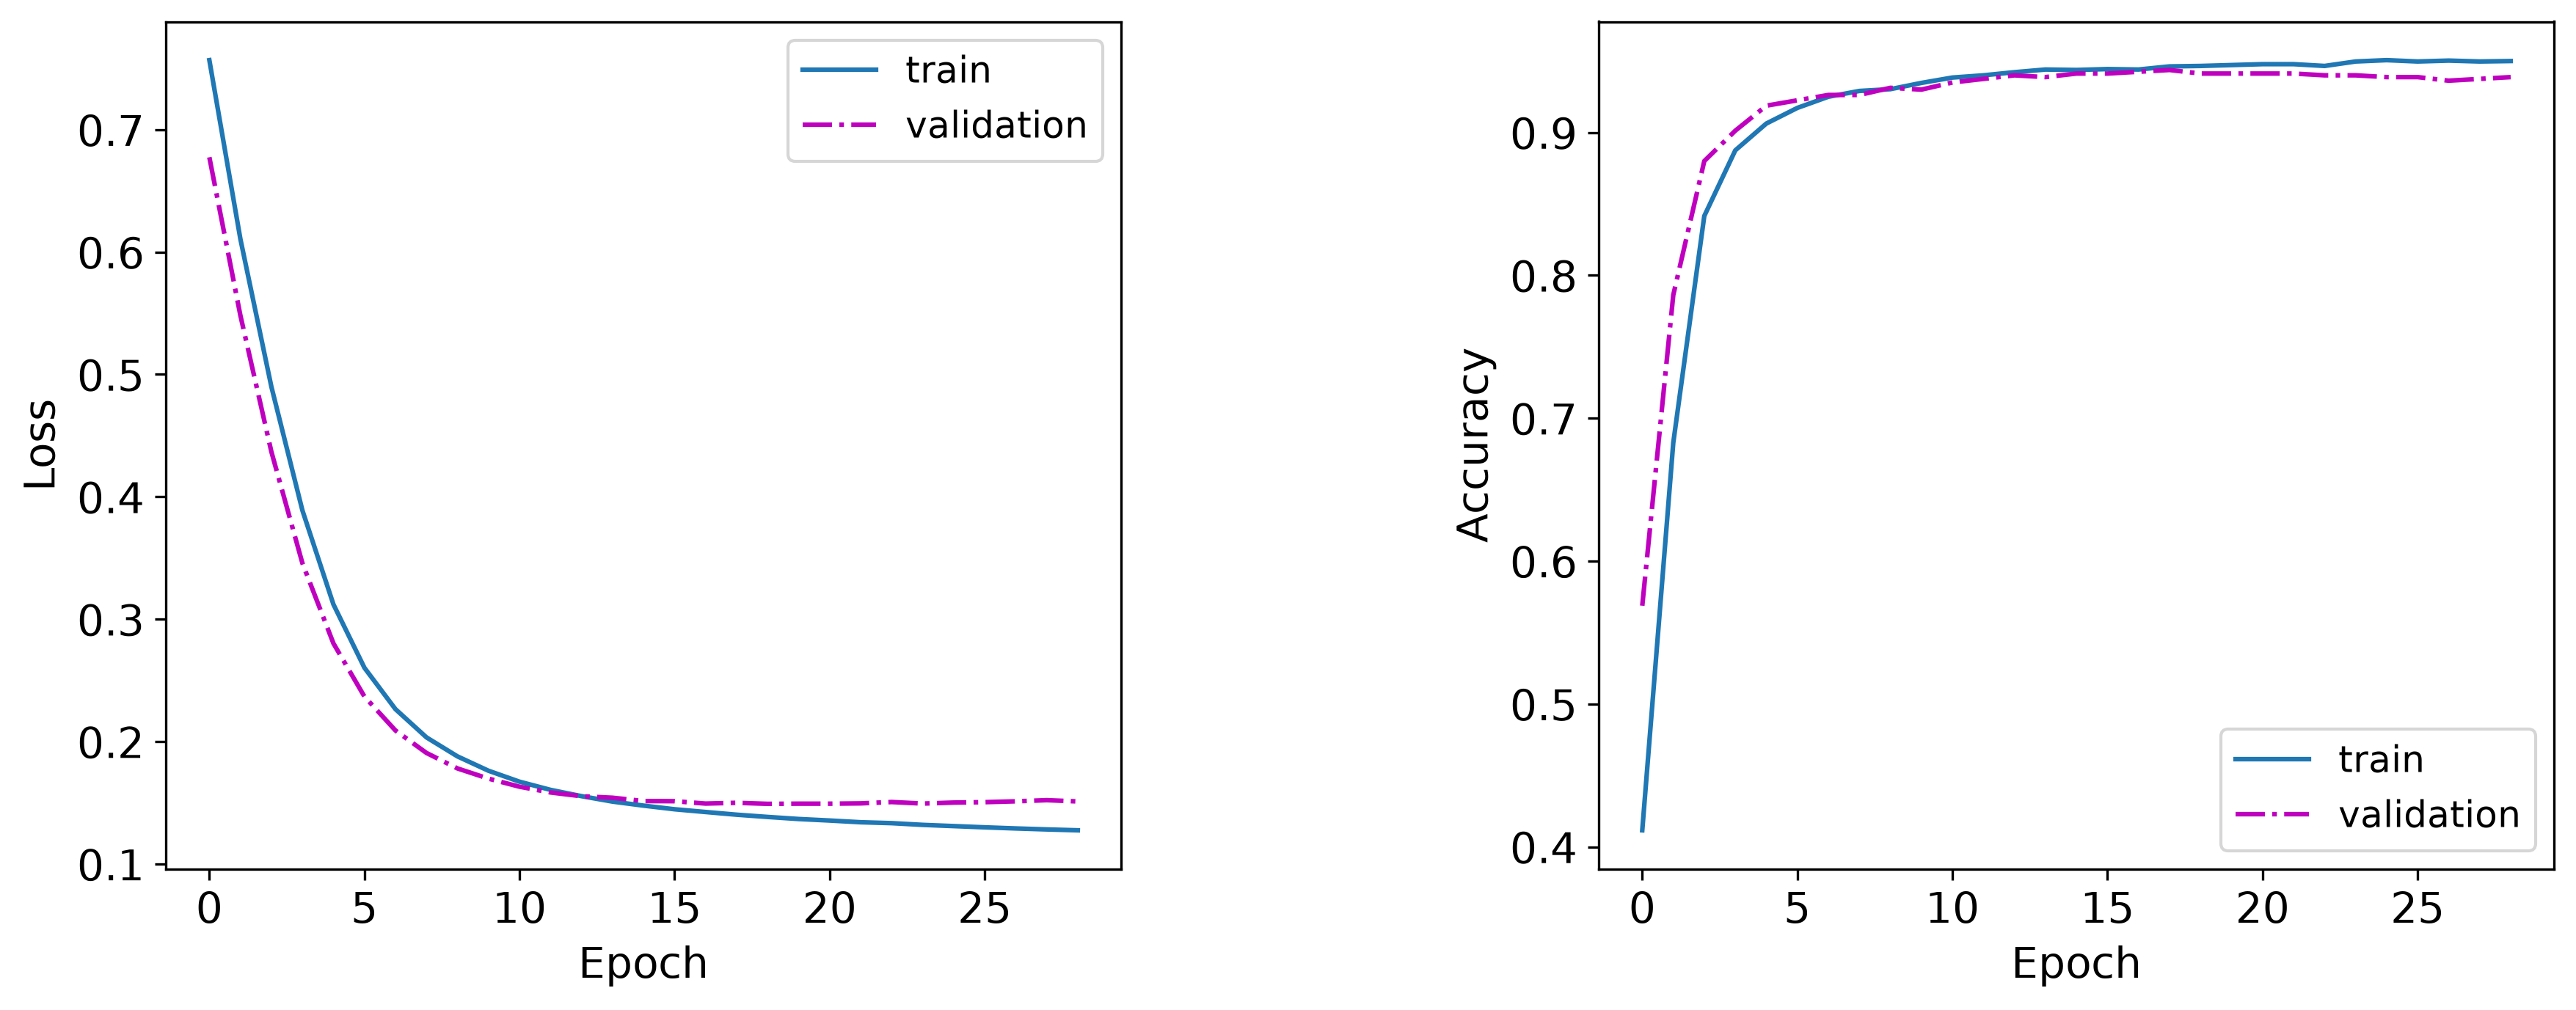

In [45]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [46]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.93625,0.175960
1,escalado + dropout,0.94000,0.151799
2,escalado + early stopping,0.93875,0.151154


In [47]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.97      0.96      0.97       838
        4top       0.82      0.84      0.83       162

    accuracy                           0.94      1000
   macro avg       0.89      0.90      0.90      1000
weighted avg       0.94      0.94      0.94      1000

AUC-ROC: 0.9758
Matriz de confusión:
[[808  30]
 [ 26 136]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.86      0.85       162

    accuracy                           0.95      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9801
Matriz de confusión:
[[812  26]
 [ 23 139]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.82      0.83      0.83       16

In [48]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.93625,0.975817,100
1,dropout,0.94000,0.980052,100
2,early stopping,0.94125,0.979301,29


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique


si la parte de early stopping, ya que al detenerse por completo es intuitivo que tendra una menor precisión en comparación al modelo sin regularizar lo que no esperaba era que el dropout tuviera mas precisión que al modelo base

2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?

Dado que la cantidad de datos no es muy grande dropout es una mejor estrategia ya que la ganancia de usar early stopping es despreciable
 
3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?

Creo que si tendria sentido por que el early stopping aun podria mejorar la precisión pero para antes de tiempo y el dropout llega hasta el final siendo que probablemente la parte final no incremento de manera significativa el modelo


4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.
drop out mejoro cuando la primera oculta se usa con un dropout alto de 0.3-0.4

el early stopping consiguio la menor distancia entrelas curvas de accuracy con una paciencia de 24 pero las curvas de perdida siguen teniendo una separación 






### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?

1 o 2 capas ya que anteriormente 2 capas de 5 neuronas fueron el mejor modelo por lo que agregar profundidad no ayudo.

- ¿Dropout va a terminar en 0.0 o en un valor alto?

Esperaría un valor bajo pero no 0.0. Si el buscador también encuentra arquitecturas chicas, esas necesitan menos regularización, por lo que el dropout óptimo debería ser modesto (0.0< x <0.2) más que alto.

- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?

Más cercano a 0.001, en un punto intermedio del rango explorado; probablemente algo menor a 0.01 porque valores de learning rate muy altos no parecen funcionar bien en este caso, y el modelo baseline funcionó bien con 0.001.

In [49]:
#pip install keras-tuner  #(correr una vez en Colab)


In [50]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Reloading Tuner from tuner_resultados/particle_id/tuner0.json


In [51]:
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")



Mejores hiperparámetros:
  n_neurons: 24
  n_hidden: 3
  dropout_rate: 0.1
  learning_rate: 0.00035910093218825


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [52]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/home/cristobal/venv-tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/cristobal/venv-tf/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(store)



Accuracy en test: 0.9400


In [63]:
# Resumen de los mejores trials
tuner.results_summary()

Results summary
Results in tuner_resultados/particle_id
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 02 summary
Hyperparameters:
n_neurons: 24
n_hidden: 3
dropout_rate: 0.1
learning_rate: 0.00035910093218825
Score: 0.9487500190734863

Trial 12 summary
Hyperparameters:
n_neurons: 64
n_hidden: 3
dropout_rate: 0.30000000000000004
learning_rate: 0.0007905622659491709
Score: 0.9487500190734863

Trial 05 summary
Hyperparameters:
n_neurons: 56
n_hidden: 1
dropout_rate: 0.2
learning_rate: 0.0016380235981496075
Score: 0.9474999904632568

Trial 07 summary
Hyperparameters:
n_neurons: 24
n_hidden: 2
dropout_rate: 0.0
learning_rate: 0.005768978937447539
Score: 0.9449999928474426

Trial 13 summary
Hyperparameters:
n_neurons: 64
n_hidden: 3
dropout_rate: 0.30000000000000004
learning_rate: 0.0002574849585348219
Score: 0.9437500238418579

Trial 11 summary
Hyperparameters:
n_neurons: 16
n_hidden: 2
dropout_rate: 0.30000000000000004
learning_rate: 0.0009271779355519417
Sc

### Mire los 5 mejores trials, no solo el ganador

1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?

Sí: el Trial 02 y el Trial 12 empatan exactamente en val_accuracy (0.94875), pero son arquitecturas muy distintas. Trial 02 usa 24 neuronas, 3 capas ocultas y dropout 0.1 en cambio el Trial 12 usa 64 neuronas, también 3 capas ocultas, pero dropout 0.3. El Trial 12 tiene muchos más parámetros pero compensa con más regularización, y termina en exactamente el mismo score que una red mucho más chica.

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?

Este empate muestra que tamaño de red y dropout no son independientes si no que un "una por otra". Una red grande (64 neuronas) necesita más dropout (0.3) para no sobreajustar y llegar al mismo desempeño que una red chica (24 neuronas) con poco dropout (0.1). Esto confirma que dropout es algo que ayuda dependiendo de la arquitectura.

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)

Elegiría el Trial 02 (24 neuronas, 3 capas, dropout 0.1). Con el mismo val_accuracy que el Trial 12, ya que significa menos parámetros que implican menor costo de cómputo, menor riesgo de sobreajustar, y un modelo más fácil de mantener e interpretar.


4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?

El mejor modelo de la búsqueda alcanzó val_accuracy 0.94875 y 0.94 en test, mientras que el mejor intento manual (dropout) llegó a val_accuracy 0.94375 y AUC-ROC 0.9786 en test. La diferencia en accuracy es de apenas medio punto porcentual. La búsqueda con keras_tuner tomó cerca de 13 minutos (15 trials x 30 épocas), mientras que el modelo manual con dropout se entrenó en una sola pasada. El costo computacional es muy alto para que valga la pena por tan poca ganancia.

### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.

Elegiría el modelo escalado + dropout como modelo final. En la tabla de comparación tiene el mejor val_accuracy de los tres modelos manuales (0.94375, contra 0.93875 de sin regularizar y 0.93875 de early stopping) y también el mejor val_loss (0.157, contra 0.174 y 0.163). Además, en el set de test (celda 88-89) tiene el mejor AUC-ROC (0.9786) y mejor f1-score en la clase minoritaria "4top" (0.87, contra 0.83 de los otros dos). El mejor modelo de la búsqueda automática (celda 98) llega a un score de validación apenas superior (0.94875) y 0.94 de accuracy en test, pero la diferencia con dropout es marginal frente al costo computacional de la búsqueda (~13 minutos vs. una sola corrida).

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?

No claramente. El mejor modelo manual (dropout) llegó a val_accuracy 0.94375 (~94.4%), y el mejor de la búsqueda automática a 0.94875 en validación / 0.94 en test — ambos dentro del mismo rango que el SVM (94-95%), sin una mejora contundente. Dado que la ganancia es tan chica (menos de 1 punto porcentual, si es que existe), probablemente no vale la pena toda la complejidad extra de la red neuronal (elegir arquitectura, regularizar, buscar hiperparámetros) solo para igualar o apenas superar un modelo más simple como el SVM. Esto es consistente con lo que se discutió antes: las NN no tienen una ventaja clara sobre métodos más simples en datos tabulares de este tamaño.

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?

El salto "sin escalar → escalado" fue mucho más grande: el modelo sin escalar entrenaba de forma muy inestable, con accuracy de validación rondando 65-75% incluso después de varias épocas, mientras que el mismo modelo con datos escalados llegó de inmediato a val_accuracy 0.93875 un salto de casi 20-25 puntos porcentuales. En cambio, el salto "escalado sin regularizar (0.93875) → mejor modelo de la búsqueda (0.94875)" es de apenas 1 punto porcentual. Esto deja una lección clara: antes de invertir tiempo afinando arquitectura, regularización o hiperparámetros, hay que asegurarse de que el preprocesamiento básico (como escalar los datos) esté bien hecho — ese paso tiene, por lejos, el mayor retorno en desempeño, mientras que el ajuste fino de hiperparámetros da ganancias mucho más marginales.